# Teaching a 'Large' Language Model to Perform Addition And Subtraction

In [29]:
# import the libraries we need
import torch
from torch import nn
from torch.nn import functional as F
import random
import math
import re
import time
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os
import zipfile
import shutil
from tqdm import tqdm
import pandas as pd

## step 1: construct a tokenizer

Our complete set of tokens is:  
`{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, +, -, =, [PAD], [EOS]}`  

Note that since our digits are 0–9, the token IDs for the other symbols follow sequentially:  
- `+` is assigned token ID **10**  
- `-` is assigned token ID **11**  
- `=` is assigned token ID **12**
- `[PAD]`is assigned token ID **13**
- `[EOS]`is assigned token ID **14**

In [2]:
# special token
pad_token="[PAD]"
eos_token="[EOS]"

class character_level_tokenizer:
    """
    character-level
    """
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {v : k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k : v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"

    def clean(self, text):
        """
        removes all characters not in the vocabulary
        """
        out = re.sub(self.pattern, "", text)
        return out

    def pre_tokenization(self, text):
        """
        character-level
        """
        return [c for c in text]

    def encode(self, text):
        text_list = self.pre_tokenization(self.clean(text))
        return [self.token_to_id[c] for c in text_list]

    def decode(self, token_list):
        return "".join([self.id_to_token[x] for x in token_list])


Let's test our tokenizer...

In [3]:
tokenizer = character_level_tokenizer()

ntokens = tokenizer.ntokens
print(f'Number of tokens in the vocabulary: {ntokens}')

prompt = "12 + 42 = "
inputs = tokenizer.encode(prompt)
print(f'\nPrompt: {prompt}')
print(f'Input: {inputs}')
print(f'Input tokenized: {tokenizer.decode(inputs)}')


prompt_answer = "42 - 12 = 30"
inputs = tokenizer.encode(prompt_answer)
print(f'\nPrompt: {prompt_answer}')
print(f'Input: {inputs}')
print(f'Input tokenized: {tokenizer.decode(inputs)}')

Number of tokens in the vocabulary: 15

Prompt: 12 + 42 = 
Input: [1, 2, 10, 4, 2, 12]
Input tokenized: 12+42=

Prompt: 42 - 12 = 30
Input: [4, 2, 11, 1, 2, 12, 3, 0]
Input tokenized: 42-12=30


In [4]:
#%% create a suite of queries to check the carry
def convert_datapoint(a_int,b_int, operation="+"):
    """
    returns a string containing two given numbers and their sum
    """
    if operation == "+":
        result_int = a_int + b_int
    elif operation == "-":
        result_int = a_int - b_int
    else:
        raise ValueError("operation must be either '+' or '-'")
    return (str(a_int) + operation + str(b_int) + "=", str(result_int))

# build a series with a carry
carry_cases = [(95, 7), (99, 8), (109, 95), (487, 596), (999, 1)]
borrow_cases = [(100, 1), (302, 58), (500, 275), (1000, 1), (901, 457), (5, 9), (12, 45), (0, 7), (123, 456)]

data_series = []
for a, b in carry_cases:
    data_series.append(convert_datapoint(a, b, operation="+"))
for a, b in borrow_cases:
    data_series.append(convert_datapoint(a, b, operation="-"))

print(data_series)

[('95+7=', '102'), ('99+8=', '107'), ('109+95=', '204'), ('487+596=', '1083'), ('999+1=', '1000'), ('100-1=', '99'), ('302-58=', '244'), ('500-275=', '225'), ('1000-1=', '999'), ('901-457=', '444'), ('5-9=', '-4'), ('12-45=', '-33'), ('0-7=', '-7'), ('123-456=', '-333')]


## step 2: create a dataset for addition operations

We will constrain the numbers in our queries to have a maximum of **3 digits (including the minus)** (0 to 999). This gives approximately **1,000,000 possible queries**, with the largest result being **1,998** (999 + 999) and the smallest **-999** (0 - 999). 

> **Note:** `10 + 12` is considered a different query from `12 + 10` since they generate different input strings for the model.


In [5]:
def sample_datapoint(number_digits = 3):
    """
    returns a string containing two random numbers with `number_digits` and their sum.
    """
    # TODO: let's sample some data points to train our model 
    # generate operand 1
    a_list = [random.randint(0, 9) for _ in range(number_digits)]
    a_int = int("".join([str(x) for x in a_list]))
    # generate operand 2
    b_list = [random.randint(0, 9) for _ in range(number_digits)]    
    b_int = int("".join([str(x) for x in b_list]))
    # compute ground-truth sum
    operation = "+" if random.randint(0,1) == 0 else "-"
    if operation == "+":
        sum_int = a_int + b_int
    else:
        sum_int = a_int - b_int
    # setup datapoint
    return (str(a_int) + operation + str(b_int) + "=", str(sum_int))

sample_datapoint(3)

('767+754=', '1521')

We can now define our data parameters and create a dataset with a given number of samples.
**Task 2.2:** Using the function above, generate a large dataset and split it into a training set (80%) and a test set (20%). Make sure there is no overlap between the two splits.  
*Hint:* Use rejection sampling to avoid overlapping samples.

In [6]:
# dataset parameters
number_digits = 3
dataset_size = 50000
train_proportion = 0.8 # 80% training, 20% validation
train_size = int(train_proportion * dataset_size)
test_size = dataset_size - train_size

# TODO: generate a train and test set without overlaping using rejection sampling
# generate a training dataset 
data_train = [sample_datapoint(number_digits) for _ in range(train_size)]

# generate test dataset using rejection sampling to avoid overlaping between train and test datasets
data_test = []
while len(data_test) < test_size:
    sample = sample_datapoint(number_digits)
    if not(sample in data_train):
        data_test.append(sample)
    
# print some outputs    
print(len(data_train),len(data_test))
print(data_train[:4], data_test[:4])

40000 10000
[('73+234=', '307'), ('337-720=', '-383'), ('888-327=', '561'), ('618-962=', '-344')] [('746+811=', '1557'), ('94+325=', '419'), ('931+516=', '1447'), ('519+307=', '826')]


## step 3: positional encoding

LLMs work with sequence data — in our case, sequences of tokens. However, transformers process all tokens in a sequence **in parallel**, so they don’t inherently know the **order** of words. Positional encoding is a technique that **adds information about the position of each token**, allowing the model to understand the sequence order.


#### How it works
1. Each token is converted into an **embedding vector** that represents its meaning.  
2. A **positional encoding vector** is added to each token embedding. This vector encodes the token’s position in the sequence.  
3. The resulting vectors carry both **semantic information** (from the token embedding) and **positional information** (from the positional encoding).

#### Common Approach
The original Transformer paper uses **sinusoidal functions** to encode positions:

$$
\text{PE}_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad
\text{PE}_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)
$$

- `pos` = position in the sequence  
- `i` = dimension index  
- `d` = embedding size  

This ensures each position in the sequence has a **unique pattern**, helping the model learn relative positions between tokens.

**TASK 3:** Implement a PyTorch module that performs the positional encoding as described above.

In [7]:
class PositionalEncoding(nn.Module):
    r"""Inject some information about the relative or absolute position of the tokens in the sequence.
        The positional encodings have the same dimension as the embeddings, so that the two can be summed.
        Here, we use sine and cosine functions of different frequencies.
    .. math:
        \text{PosEncoder}(pos, 2i) = sin(pos/10000^(2i/d_model))
        \text{PosEncoder}(pos, 2i+1) = cos(pos/10000^(2i/d_model))
        \text{where pos is the word position and i is the embed idx)
    Args:
        d_model: the embed dim (required).
        dropout: the dropout value (default=0.1).
        max_len: the max. length of the incoming sequence (default=5000).
    """

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # TODO: compute positional ecoding
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)) # log exp trick for stability
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        # pytorch buffer
        self.register_buffer('pe', pe)

    def forward(self, x):
        r"""Inputs of forward function
        Args:
            x: the sequence fed to the positional encoder model (required).
        Shape:
            x: [sequence length, batch size, embed dim]
            output: [sequence length, batch size, embed dim]
        """
        # TODO: apply positional encoding
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

Let's visualize the position encoding in 2 dimensions

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


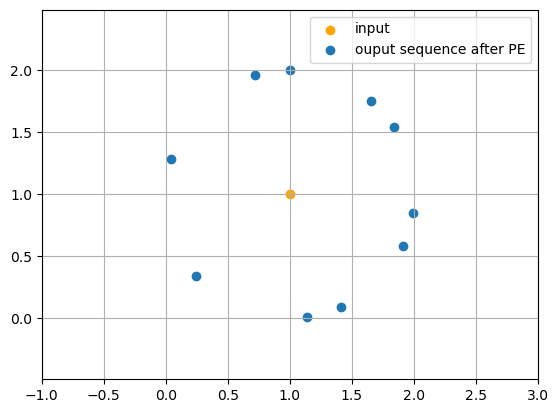

In [8]:
PE = PositionalEncoding(d_model=2,dropout=0)
# create tensor with the same vector
x = torch.ones((10,1,2)) #[seq lenght x batch x dim]
# apply PE and check out the result
y = PE(x)

# plot
plt.scatter(1,1,c='orange',label='input')
plt.scatter(y[:,0,0],y[:,0,1],label='ouput sequence after PE')
plt.axis('equal')
plt.xlim((-1,3))
plt.ylim((-1,3))
plt.grid('on')
plt.legend()

## step 4: build the model

We will use a simpler **Transformer** network with **causal attention**.  In causal attention, each token can only attend to itself and the previous tokens in the sequence — it cannot “see the future.” This ensures that when predicting the next token, the model cannot cheat by looking ahead, which is essential for our addition task.  The attention mask can be represented as a matrix, where `1` means attention is allowed and `0` means it is blocked:


<div align="center">

|       | 1 | + | 2 | = |
|-------|---|---|---|---|
| **1** | 1 | 0 | 0 | 0 |
| **+** | 1 | 1 | 0 | 0 |
| **2** | 1 | 1 | 1 | 0 |
| **=** | 1 | 1 | 1 | 1 |

</div>

- **Row** = current token being predicted  
- **Column** = token the current token can attend to  

For example, when predicting `2` (the third token), it can attend to `1` and `+`, but not `=` yet.


> Our final model follows the flow below:

$$
\begin{align*}
\text{Input tokens} &\rightarrow \text{Embedding} \\
&\rightarrow \text{Positional Encoding} \\
&\rightarrow \text{Transformer Encoder (masked)} \\
&\rightarrow \text{Linear Decoder} \\
&\rightarrow \text{Log-softmax output}
\end{align*}
$$

- **Input tokens**: Sequence of token indices (digits, `+`, `=`, etc.) representing the addition problem.  
- **Embedding**: Converts token indices to dense vectors with `ninp` dimensions.  
- **Positional Encoding**: Adds information about the position of each token in the sequence.  
- **Transformer Encoder (masked)**: Applies self-attention only to previous tokens (causal), ensuring each prediction depends only on tokens that came before.  
- **Linear Decoder**: Projects encoder outputs to the size of the vocabulary.  
- **Log-softmax output**: Produces log-probabilities for the next token in the sequence.

**Task 4:** Implement the forward pass of the `TransformerModel` below, following the steps described above.


In [9]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        # Capture the attention weights by setting need_weights=True
        src2, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False  # (B, num_heads, S, S)
        )
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, 0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, sz):
        # TODO: generate a LxL casual attention mask
        return torch.log(torch.tril(torch.ones(sz,sz)))

    def forward(self, src):        
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        # TODO: Inference of the model
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask)
        output_dec = self.decoder(output_enc)
        # Gather attention maps from all encoder layers
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps


Let's setup our model have a look in it

In [10]:
# instantiate the model and check it
model = TransformerModel(ntoken = ntokens,
                         ninp = 128,
                         nhead = 16,
                         nhid = 64,
                         nlayers = 6)
# print(model)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

# size of the model
model.train() 
Nparams = sum(p.numel() for p in model.parameters())
Nparams_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'parameters: {Nparams}, trainable parameters: {Nparams_train}')

# run a simple data point through the model
input_data = ["2+2=", "5-2="]
input_data = [tokenizer.encode(x) for x in input_data]
input_data = torch.Tensor(input_data).long().to(device).view(4, 2)
output_data, _, _ = model(input_data)
print(output_data.shape)
print(output_data)


/mnt/hpccs01/home/fonseca2/micromamba/envs/analysis/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


cuda
parameters: 502671, trainable parameters: 502671
torch.Size([4, 2, 15])
tensor([[[-1.9351, -3.8145, -3.3722, -1.6907, -4.7617, -2.6433, -2.8784,
          -2.6210, -3.0212, -3.3712, -3.5682, -2.5047, -2.0728, -2.9150,
          -3.4064],
         [-2.7619, -2.3878, -3.3365, -3.3040, -3.9036, -2.7559, -1.8419,
          -2.3136, -2.7373, -2.8756, -2.2342, -3.1596, -2.8813, -2.5905,
          -3.5107]],

        [[-2.0236, -3.9825, -3.6636, -2.1033, -3.7482, -2.1068, -3.0487,
          -2.5000, -3.0744, -3.3534, -3.1308, -2.4540, -2.3075, -2.3758,
          -3.7499],
         [-2.2373, -2.7543, -3.2403, -3.0897, -3.7011, -2.5391, -2.2146,
          -2.2787, -2.8774, -3.6820, -2.2521, -3.2721, -3.1064, -2.0580,
          -3.4219]],

        [[-1.5440, -3.4237, -3.6221, -2.2227, -4.2655, -2.2772, -3.5975,
          -2.8387, -3.6867, -3.1052, -2.8755, -2.7498, -2.6420, -2.0990,
          -3.4310],
         [-2.2419, -2.7267, -3.3734, -2.8499, -4.0153, -2.5654, -2.0425,
          -2.434

## Step 5: Handling functions 

### Autoregressive Token Generator

Our Transformer so far takes a sequence of tokens as input and predicts the probability (or log-probability) of the **next token** in our vocabulary.  

To generate new sequences, we use an **autoregressive generation function**. This function takes a sequence of input tokens (`prompts`) and produces `new_tokens` additional tokens **one by one**, always feeding back the previously generated tokens into the model to predict the next one. The final output is the full sequence: the original prompt plus the newly generated tokens.

**Task 5:** Complete the generate function below by implementing the autoregressive prediction. Make sure the function:
- Feeds the previously generated tokens back into the model at each step.
- Appends the newly predicted token to the input sequence.
- Returns the full sequence including the original prompt and all generated tokens.

In [11]:
def generate(model, prompts, new_tokens = 5):
    input_tensor = prompts # (length_prompts, batch_size)
    input_tensor = input_tensor.to(device)
    for _ in range(new_tokens):
        # TODO: let's implement autoregressive prdiction. The model needs to predict the next toke from the previous in sequence.
        output, _, _ = model(input_tensor) # (length_prompts, batch_size, ntokens)
        last_output = output[-1,:,:] # (batch_size, ntokens)
        token = torch.argmax(last_output, -1).view((1,-1)) # (1, batch_size)
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor

Let's try our Autoregressive Token Generator.  

> **Note:** The model is not trained yet, so the addition results will be incorrect. However, the **format** of the inputs and outputs will be correct, which allows us to test the generation pipeline.

In [12]:
# try to generate 5 new tokens
model.eval()
prompt = "2-3="
print(f'prompt: {prompt}')
prompt_tensor = torch.tensor(tokenizer.encode(prompt)).view((-1,1))
print(f'prompt encoded: {prompt_tensor}')
output = generate(model, prompt_tensor, new_tokens = 5).view((1,-1))
print(f'output: {output}')
print(f'output decoded: {tokenizer.decode(output.tolist()[0])}')

prompt: 2-3=
prompt encoded: tensor([[ 2],
        [11],
        [ 3],
        [12]])
output: tensor([[ 2, 11,  3, 12,  0, 10,  0, 10,  0]], device='cuda:0')
output decoded: 2-3=0+0+0


### Sequence Padding and Masking

Transformers process batches of sequences (prompts) in parallel. However, these sequences can have different lengths, which makes it difficult to use them directly, since most neural network backbones expect tensors with consistent shapes.  

To efficiently train on multiple examples at once, we use **padding** and **masking**:

- **Padding**: `<pad>` tokens are added as placeholders so that shorter sequences “fit” into the same tensor size as longer ones.  
- **Masking**: During training, we provide an **attention mask** to tell the model to ignore padded positions, so it does not accidentally learn from them.  
- **Prompts**: Padding ensures that all input sequences align properly when batching.  
- **Answers**: We insert an `<eos>` (end-of-sequence) token so the model knows where the answer ends, then pad to equalize sequence lengths.  

In [13]:
def pad(token_list, type_list = "prompts"):
    assert type_list in ['prompts', 'answers']
    # pad so that all the prompt have the same number of tokens
    max_length = max([len(x) for x in token_list])
    out = []
    for x in token_list:
        if type_list == "prompts":
            out.append([tokenizer.token_to_id[pad_token]] * (max_length - len(x)) + x) # padding + sequence
        if type_list == "answers":
            out.append(x + [tokenizer.token_to_id[eos_token]] + [tokenizer.token_to_id[pad_token]] * (max_length - len(x))) # sequence + eos + padding                    
    return out, max_length

In [14]:
prompts = [tokenizer.encode("1+0="), tokenizer.encode("21-35=")]
answers = [tokenizer.encode("1"), tokenizer.encode("-14")]
padded_prompts, _ = pad(prompts, "prompts")
padded_answers, _ = pad(answers, "answers")
for p in prompts: 
    print(f'Prompts : {tokenizer.decode(p)}')
for p in answers: 
    print(f'Answers : {tokenizer.decode(p)}')
for p in padded_prompts: 
    print(f'Prompts padded: {tokenizer.decode(p)}')
for p in padded_answers:
    print(f'Answers padded: {tokenizer.decode(p)}')

Prompts : 1+0=
Prompts : 21-35=
Answers : 1
Answers : -14
Prompts padded: [PAD][PAD]1+0=
Prompts padded: 21-35=
Answers padded: 1[EOS][PAD][PAD]
Answers padded: -14[EOS]


### Batchfy Dataset

We need a function to draw a batch from the datasets since we don't use pytorch dataloader

In [15]:
batch_size=100
def get_batch(data, i):
    prompts = [tokenizer.encode(data[i][0]) for i in range(i, i + batch_size)]
    padded_prompts, length_prompts = pad(prompts, "prompts")
    answers = [tokenizer.encode(data[i][1]) for i in range(i, i + batch_size)]
    padded_answers, length_answers = pad(answers, "answers")
    X = torch.stack([torch.tensor(x) for x in padded_prompts], 1)
    Y = torch.stack([torch.tensor(x) for x in padded_answers], 1)
    return X, Y, length_prompts, length_answers

# create a batch for training from position 243 until 243 + batchsie
X, Y, length_prompts, length_answers = get_batch(data_train, 243)
X.shape, Y.shape, length_prompts, length_answers

(torch.Size([8, 100]), torch.Size([5, 100]), 8, 4)

As a sanity check, run the model on a series of 10 consecutive queries to observe how it works.
> **NOTE:** The results should be **nonsensical**, since the model still has **random weights**


In [16]:
model.eval()
print(' Testing the model on a series of numbers to check the carry\n')
for i in range(len(data_series)):
    prompt, answers = data_series[i]
    prompt_tensor = torch.tensor(tokenizer.encode(prompt)).view((-1,1))    
    output = generate(model, prompt_tensor, 5).view((1,-1))
    print(tokenizer.decode(output.tolist()[0]) + "\t actual result: " + answers)

 Testing the model on a series of numbers to check the carry

95+7=00000	 actual result: 102
99+8=00000	 actual result: 107
109+95=00000	 actual result: 204
487+596=00+0+	 actual result: 1083
999+1=00000	 actual result: 1000
100-1=0000+	 actual result: 99
302-58=0000+	 actual result: 244
500-275=0+0+0	 actual result: 225
1000-1=00+0+	 actual result: 999
901-457=00000	 actual result: 444
5-9=000+0	 actual result: -4
12-45=00000	 actual result: -33
0-7=0+0+0	 actual result: -7
123-456=000+0	 actual result: -333


## Step 6: Model Performance

To monitor training, we need a way to measure how well the model predicts. The simplest metric is **accuracy**, which can be computed at either the digit level or the sequence level.  

**Digit-level accuracy** measures the percentage of correctly predicted tokens (digits):  

$$
\text{Accuracy}_{\text{digit}} = \frac{\text{Number of correct tokens}}{\text{Total number of tokens}}
$$  

This tells us how often the model predicts each digit correctly.  

**Sequence-level accuracy** measures the percentage of completely correct additions:  

$$
\text{Accuracy}_{\text{sequence}} = \frac{\text{Number of correct sequences}}{\text{Total number of sequences}}
$$  

In addition, we can compare the predicted answers (as integers) with the true answers. A **scatter plot** of predictions vs. ground truth provides a visual check — ideally, all points should fall along the diagonal line.

**Task 6:** In the `evaluate` function below, implement the computation of **digit-level accuracy** and **sequence-level accuracy**.


In [22]:
def evaluate(data):
    # compute how many digits are correctly predicted
    # Turn on evaluation mode disables dropout.
    model.eval()
    correct_digit, total_digit, correct, total = 0., 0., 0. ,0.
    with torch.no_grad():
        for batch, i in enumerate(range(0, len(data) - 1, batch_size)):            
            prompts, target_answers, length_prompts, length_answers = get_batch(data, i)            
            prompts         = prompts.to(device) # (length_prompts, batch_size)
            target_answers  = target_answers.to(device) # (length_answers + 1, batch_size)
            
            output          = generate(model, prompts, length_answers + 1) # (length_prompts + length_answers + 1, batch_size)
            answers_tokens  = output[length_prompts:, :] # (length_answers + 1, batch_size), contains tokens

            # compare predictions
            target_mask_pad = target_answers != tokenizer.token_to_id[pad_token]
            equality_test = answers_tokens == target_answers            
        
            # digit accuracy computation
            # TODO: compute digit accuracy
            correct_digit += torch.logical_and(target_mask_pad, equality_test).sum().item()
            total_digit += target_mask_pad.sum().item()
        
            # full sequence accuracy computation
            # TODO: Compute sequence accuracy
            correct += torch.all(torch.logical_or(~target_mask_pad, equality_test), axis=0).float().sum().item()
            total += target_answers.shape[-1]
        
        # TODO: compute digit and sequence accuracy
        digit_accuracy = correct_digit / total_digit
        seq_accuracy = correct / total
        
    return digit_accuracy, seq_accuracy

def errorTest(data):
    # convert model answer and target to integers
    # Turn on evaluation mode disables dropout.
    model.eval()
    num_ans = []
    num_tgt = []
    with torch.no_grad():
        for batch, i in enumerate(range(0, len(data) - 1, batch_size)):            
            # predict on a batch
            prompts, target_answers, length_prompts, length_answers = get_batch(data, i)            
            prompts         = prompts.to(device) # (length_prompts, batch_size)
            target_answers  = target_answers.to(device) # (length_answers + 1, batch_size)
            output          = generate(model, prompts, length_answers + 1) # (length_prompts + length_answers + 1, batch_size)
            answers_tokens  = output[length_prompts:, :] # (length_answers + 1, batch_size), contains tokens
            
            # compute the numerical error between tgt and answer
            n_d,n_b = answers_tokens.shape
            for idx,b in enumerate(range(n_b)):
                # go through the batch
                ans         = tokenizer.decode(answers_tokens[:,b].tolist())
                tgt         = tokenizer.decode(target_answers[:,b].tolist())
                
                
                ans_cleaned = ans.replace('[EOS]', '').replace('[PAD]', '')
                tgt_cleaned = tgt.replace('[EOS]', '').replace('[PAD]', '')
                
                try:                
                    num_ans.append(int(ans_cleaned) if ans_cleaned != '' else 0)
                    num_tgt.append(int(tgt_cleaned) if ans_cleaned != '' else 0)
                except ValueError:
                    print(f"Error converting to int: ans='{ans_cleaned}', tgt='{tgt_cleaned}'")
    num_ans = torch.tensor(num_ans)
    num_tgt = torch.tensor(num_tgt)
    return num_ans,num_tgt

test_digit_accuracy, test_seq_accuracy = evaluate(data_test)
test_digit_accuracy, test_seq_accuracy

(0.9947269131986272, 0.9791)

## Step 7: Train the model

We now have everything we need to train our large language model to perform addition. The training process follows a **sequence-to-sequence learning setup**. Given an input sequence representing an addition problem (the `prompt`), the model learns to predict the **next token at each step** in the target sequence (the `answer`). Over time, the model learns the mapping from prompts to correct answers, token by token.  

**Task 7:** In the `train_epoch` function below, implement the **next-token prediction** step. 


cuda
-----------------------------------------------------------------------------------------
| initialisation | test digit accuracy 0.087 | test seq accuracy 0.000
-----------------------------------------------------------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 296.39it/s]


Epoch   1 (15.70s), test digit accuracy:0.462, test seq accuracy:0.005, train digit accuracy:0.460, train seq accuracy:0.005, loss: 1.52


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 286.83it/s]


Epoch   2 (10.03s), test digit accuracy:0.496, test seq accuracy:0.008, train digit accuracy:0.498, train seq accuracy:0.008, loss:  1.2


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 298.72it/s]


Epoch  99 ( 9.98s), test digit accuracy:0.995, test seq accuracy:0.981, train digit accuracy:0.996, train seq accuracy:0.985, loss:0.0998


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 280.10it/s]


Epoch 100 ( 9.99s), test digit accuracy:0.995, test seq accuracy:0.979, train digit accuracy:0.996, train seq accuracy:0.983, loss: 0.11
Total training time: 16.76 min



<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

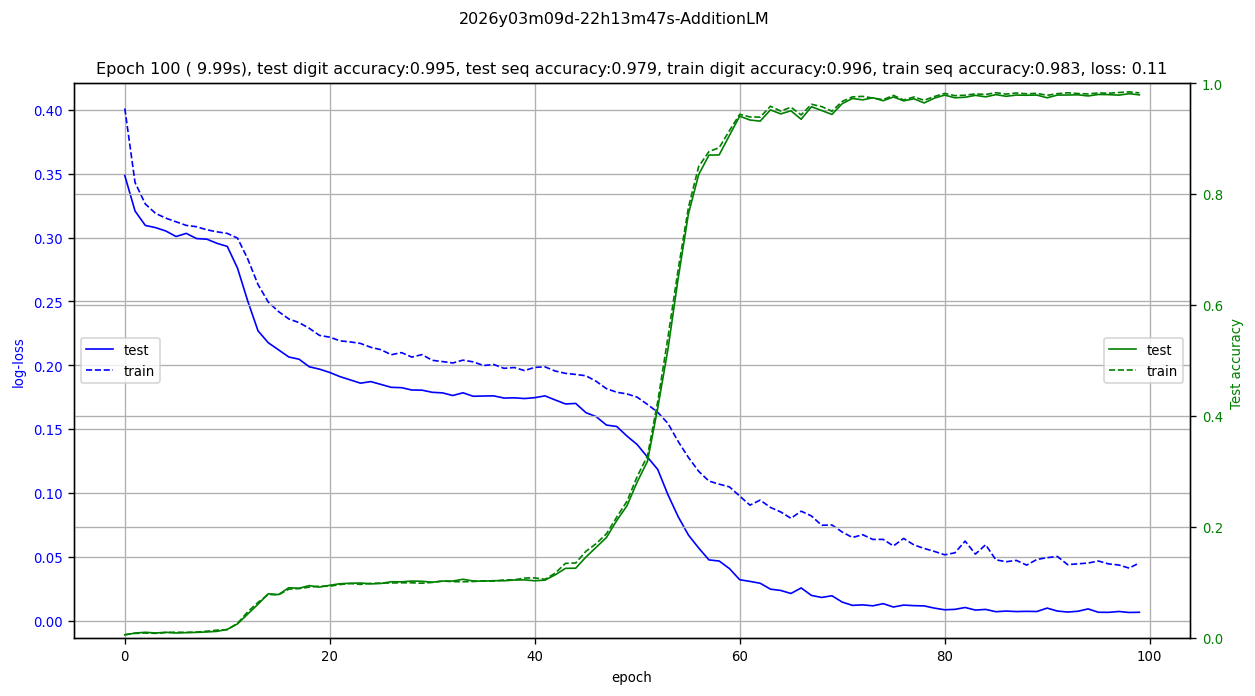

In [18]:
learning_rate = 1e-3
epochs = 100
batch_size = 100
model = TransformerModel(ntoken = ntokens,
                         ninp = 128,
                         nhead = 16,
                         nhid = 64,
                         nlayers = 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# train step
def train_epoch(epoch):
    model.train()
    

    total_loss = 0.
    n_batch = 0
    iterable = range(0, len(data_train) - 1, batch_size)
    for batch, i in tqdm(enumerate(iterable),total=len(iterable),colour='GREEN'):
        n_batch += 1
        prompts, target_answers, length_prompts, length_answers = get_batch(data_train, i)    
        # TODO: let's code next token prediction            
        prompts         = prompts.to(device) # (length_prompts, batch_size)
        target_answers  = target_answers.to(device) # (length_answers, batch_size)        
        input_tensor    = torch.cat((prompts, target_answers), 0) # (length_prompts + length_answers, batch_size)
        
        optimizer.zero_grad()
        
        output, output_enc, _ = model(input_tensor) # (length_prompts + length_answers, batch_size, ntokens)
        output_answers  = output[length_prompts-1:-1,:,:].reshape(-1, ntokens) # (length_answers * batch_size, ntokens)
        target_answers  = target_answers.view(-1)
        
        loss = F.cross_entropy(output_answers, target_answers)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
   
    total_loss  /= n_batch
    train_digit_accuracy, train_seq_accuracy   = evaluate(data_train)
    
    return total_loss, train_digit_accuracy, train_seq_accuracy
    
# test step
def test_epoch(epoch=1):
    model.eval()

    total_loss = 0.
    n_batch = 0
    iterable = range(0, len(data_test) - 1, batch_size)
    for batch, i in tqdm(enumerate(iterable),total=len(iterable)):
        n_batch += 1
        prompts, target_answers, length_prompts, length_answers = get_batch(data_test, i)
        prompts         = prompts.to(device) # (length_prompts, batch_size)
        target_answers  = target_answers.to(device) # (length_answers, batch_size)
        input_tensor    = torch.cat((prompts, target_answers), 0) # (length_prompts + length_answers, batch_size)
        
        with torch.no_grad():        
            output, output_enc, _ = model(input_tensor) # (length_prompts + length_answers, batch_size, ntokens)
        output_answers  = output[length_prompts-1:-1,:,:].reshape(-1, ntokens) # (length_answers * batch_size, ntokens)
        target_answers  = target_answers.view(-1)
        
        loss = F.cross_entropy(output_answers, target_answers)
            
        total_loss += loss.item()

    total_loss /= n_batch
    test_digit_accuracy, test_seq_accuracy  = evaluate(data_test)
    
    return total_loss, test_digit_accuracy, test_seq_accuracy

# actual loop
def train():
    train_losses4disp   = []
    test_losses4disp    = []
    test_digit_accuracy4disp  = []
    train_digit_accuracy4disp = []
    test_seq_accuracy4disp  = []
    train_seq_accuracy4disp = []
    
    AUAC_test   = 0
    AUAC_train  = 0
    best_test_accuracy = None
    test_digit_accuracy, test_seq_accuracy = evaluate(data_test)
    print('-' * 89)
    print('| initialisation | test digit accuracy {:5.3f} | test seq accuracy {:5.3f}'.format(test_digit_accuracy, test_seq_accuracy))
    print('-' * 89)
    training_start_time = time.time()
    for epoch in range(1, epochs+1):
        epoch_start_time            = time.time()
        train_loss,train_digit_accuracy,train_seq_accuracy   = train_epoch(epoch)
        test_loss,test_digit_accuracy,test_seq_accuracy     = test_epoch(epoch)
                
        train_losses4disp.append(train_loss)
        test_losses4disp.append(test_loss)
        train_digit_accuracy4disp.append(train_digit_accuracy)
        test_digit_accuracy4disp.append(test_digit_accuracy)
        train_seq_accuracy4disp.append(train_seq_accuracy)
        test_seq_accuracy4disp.append(test_seq_accuracy)
                
        # print('-' * 50)
        str_epoch = 'Epoch {:3d} ({:5.2f}s), test digit accuracy:{:5.3f}, test seq accuracy:{:5.3f}, train digit accuracy:{:5.3f}, train seq accuracy:{:5.3f}, loss:{:5.3}'.format(
            epoch, (time.time() - epoch_start_time), test_digit_accuracy, test_seq_accuracy, train_digit_accuracy, train_seq_accuracy, train_loss)
        print(str_epoch)
    
    total_training_time = (time.time()-training_start_time)/(60)
    str_time = f'Total training time: {total_training_time:.2f} min\n'
    print(str_time)
    return np.array(train_losses4disp), np.array(test_losses4disp),\
           np.array(test_digit_accuracy4disp), np.array(train_digit_accuracy4disp),\
            np.array(test_seq_accuracy4disp), np.array(train_seq_accuracy4disp),\
           (str_epoch,str_time)    


datename  = datetime.datetime.now().strftime('%Yy%mm%dd-%Hh%Mm%Ss')
genName   = datename + "-AdditionLM" 
train_losses4disp, test_losses4disp, test_digit_accuracy4disp, train_digit_accuracy4disp, test_seq_accuracy4disp, train_seq_accuracy4disp, str_results = train()
str_epoch,str_time = str_results
torch.save(model.state_dict(), genName + ".pkl")

# training/validation plots
f   = plt.figure(figsize=(12,6),dpi=120) # A4 format, square
plt.rc('font',size= 8)
#%%   losses plot
ax  = f.add_subplot(1,1,1)
ax.plot( np.log10(1.+test_losses4disp),color='b',label='test',linewidth=1)
ax.plot( np.log10(1.+train_losses4disp),color='b',linestyle='--',label='train',linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("log-loss",color='b')
ax.tick_params(axis='y', labelcolor='b')
ax.set_title(str_epoch)
ax.legend(loc='center left')
plt.grid()

#%%   accuracy plot
ax2 = ax.twinx()
ax2.plot( test_seq_accuracy4disp ,color='green',label='test',linewidth=1)
ax2.plot( train_seq_accuracy4disp ,color='green',linestyle='--',label='train',linewidth=1)
ax2.set_xlabel("epoch")
ax2.set_ylabel("Test accuracy ",color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc = 'center right')
ax2.set_ylim((0,1)) 
plt.grid()

f.suptitle(genName)
plt.tight_layout



### Let's check our trained model

Test the trained model on a few examples.

In [ ]:
# in case you do not want to train. You can load a pretrained model by running this cell

model = TransformerModel(ntoken = ntokens,
                         ninp = 128,
                         nhead = 16,
                         nhid = 64,
                         nlayers = 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)
model.load_state_dict(torch.load('pretrained-AdditionLM.pkl'))

cuda


/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

In [30]:
# Run inference on the entire test dataset
model.eval()

op1_list, op2_list, operation_list, target_list, answer_list = [], [], [], [], []

with torch.no_grad():
    for idx in tqdm(range(len(data_test)), desc="Running inference on test set", colour='CYAN'):
        prompt, target = data_test[idx]
        
        # Extract operation (+ or -)
        if '+' in prompt:
            operation = '+'
            operands = prompt.replace('=', '').split('+')
        else:
            operation = '-'
            operands = prompt.replace('=', '').split('-')
        
        op1 = int(operands[0])
        op2 = int(operands[1])
        
        # Generate prediction
        prompt_tensor = torch.tensor(tokenizer.encode(prompt)).view((-1, 1)).to(device)
        output = generate(model, prompt_tensor, 5).view((1, -1))
        
        # Extract predicted answer
        pred_tokens = output.tolist()[0]
        
        # Find the index of '=' token (token_id = 12) and extract answer after it
        if 12 in pred_tokens:
            answer_start_idx = pred_tokens.index(12) + 1
            answer_tokens = pred_tokens[answer_start_idx:]
            
            # Convert tokens to string, handling digits (0-9) and minus sign (token 11)
            answer_str = ''.join([str(d) if (0 <= d <= 9) else '-' for d in answer_tokens if (0 <= d <= 9) or (d == 11)])
            
            try:
                pred_answer = int(answer_str) if answer_str and answer_str != '-' else 0
            except ValueError:
                pred_answer = 0
        else:
            pred_answer = 0
        
        # Store results
        op1_list.append(op1)
        op2_list.append(op2)
        operation_list.append(operation)
        target_list.append(int(target))
        answer_list.append(pred_answer)

    

df_results = pd.DataFrame({'OP1': op1_list, 'OP2': op2_list, 'Operation': operation_list, 'Target': target_list, 'Prediction': answer_list})
df_results

Running inference on test set: 100%|██████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:42<00:00, 97.50it/s]


,OP1,OP2,Operation,Target,Prediction
0,746,811,+,1557,1557
1,94,325,+,419,1298
2,931,516,+,1447,1447
3,519,307,+,826,826
4,179,716,-,-537,-537
...,...,...,...,...,...
9995,656,100,+,756,756
9996,734,93,+,827,1666
9997,961,279,-,682,682
9998,192,426,-,-234,-234


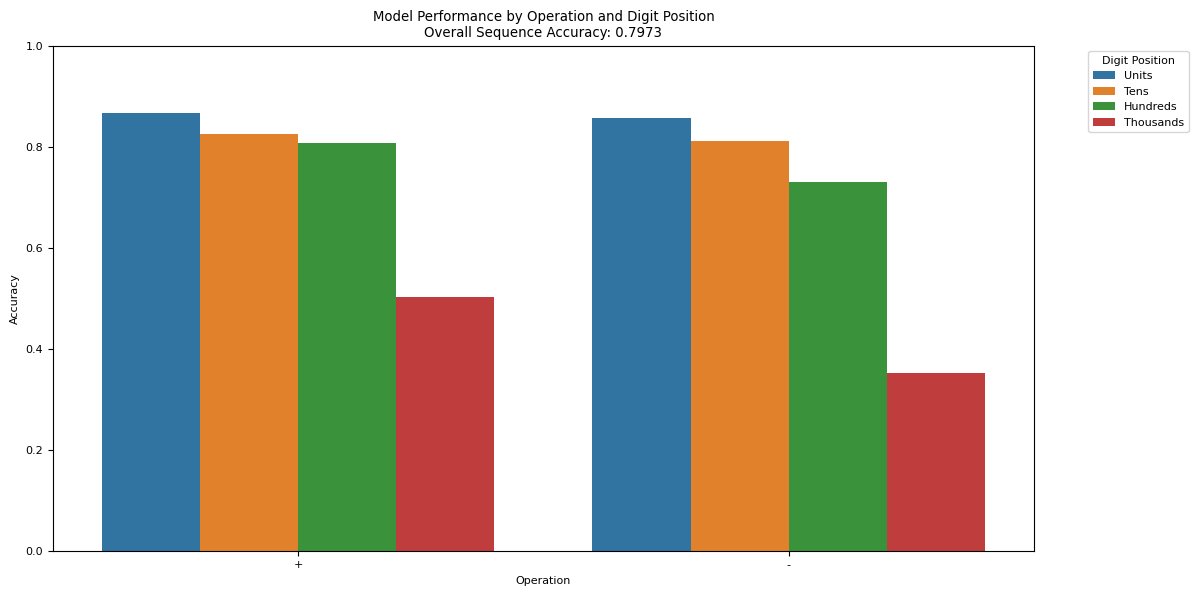


=== Overall Performance ===
Sequence-level Accuracy: 0.7973
Carry Cases Accuracy: 0.8376
Borrow Cases Accuracy: 0.7877

=== Detailed Results ===
Operation  Position  Accuracy  Support
        +     Units  0.865534     5005
        +      Tens  0.824376     5005
        +  Hundreds  0.807792     4979
        + Thousands  0.502098     2513
        -     Units  0.856857     4995
        -      Tens  0.810410     4953
        -  Hundreds  0.728929     4509
        - Thousands  0.352352     2038


In [41]:
# Create a copy of df_results to work with
df_analysis = df_results.copy()

# Sequence-level correctness
df_analysis['Correct'] = df_analysis['Target'] == df_analysis['Prediction']
overall_seq_accuracy = df_analysis['Correct'].mean()

# check for carry and borrow cases
df_analysis['Carry'] = df_analysis.apply(lambda row: (row.Operation == '+' and ((row.OP1 % 10 + row.OP2 % 10) >= 10 or (row.OP1 // 10 % 10 + row.OP2 // 10 % 10) >= 10 or (row.OP1 // 100 % 10 + row.OP2 // 100 % 10) >= 10)) , axis=1)
df_analysis['Borrow'] = df_analysis.apply(lambda row: (row.Operation == '-' and ((row.OP1 % 10 < row.OP2 % 10) or (row.OP1 // 10 % 10 < row.OP2 // 10 % 10) or (row.OP1 // 100 % 10 < row.OP2 // 100 % 10))) , axis=1)
carry_accuracy = df_analysis[df_analysis.Carry == True]['Correct'].mean()
borrow_accuracy = df_analysis[df_analysis.Borrow == True]['Correct'].mean()


accuracy_matrix = []
for op in ['+', '-']:    
    for position, digit_name in enumerate(['Units', 'Tens', 'Hundreds', 'Thousands', 'Ten Thousands']):
        target_digit = df_analysis[df_analysis.Operation == op].apply(lambda row: str(row.Target)[::-1][position] if position < len(str(row.Target)) else np.nan, axis=1)
        prediction_digit = df_analysis[df_analysis.Operation == op].apply(lambda row: str(row.Prediction)[::-1][position] if position < len(str(row.Prediction)) else np.nan, axis=1)    
        accuracy_matrix.append((op, digit_name, (target_digit == prediction_digit).mean(), target_digit.notna().sum()))



# Create DataFrame from accuracy_matrix
report_df = pd.DataFrame(accuracy_matrix, columns=['Operation', 'Position', 'Accuracy', 'Support'])
# Filter out positions with zero support
report_df_filtered = report_df[report_df['Support'] > 0].copy()

# Create a barplot using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=report_df_filtered, x='Operation', y='Accuracy', hue='Position', 
            hue_order=['Units', 'Tens', 'Hundreds', 'Thousands'])
plt.title(f'Model Performance by Operation and Digit Position\nOverall Sequence Accuracy: {overall_seq_accuracy:.4f}')
plt.ylabel('Accuracy')
plt.xlabel('Operation')
plt.ylim(0, 1)
plt.legend(title='Digit Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Display summary statistics
print(f"\n=== Overall Performance ===")
print(f"Sequence-level Accuracy: {overall_seq_accuracy:.4f}")
print(f"Carry Cases Accuracy: {carry_accuracy:.4f}")
print(f"Borrow Cases Accuracy: {borrow_accuracy:.4f}")
print(f"\n=== Detailed Results ===")
print(report_df_filtered.to_string(index=False))